# 8.1 Домашнее задание. Конкурс на Kaggle — Churn Prediction

**Задача:** бинарная классификация — прогноз оттока клиентов.  
**Метрика:** ROC-AUC.  
**Данные:** train.csv (5282 строки), test.csv (1761 строка).

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Загрузка данных (2 балла)

In [2]:
data = pd.read_csv('data/train.csv')
print(f'Размер датасета: {data.shape}')
data.sample(10, random_state=42)

Размер датасета: (5282, 20)


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1448,9,45.40,418.8,Male,0,No,No,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,1
4792,37,70.35,2552.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,0
8,50,105.95,5341.8,Male,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,No,Credit card (automatic),1
3964,44,100.10,4378.35,Male,0,No,No,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),0
240,25,20.95,495.15,Male,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),0
1942,39,50.75,2011.4,Female,0,No,No,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,1
1859,52,79.20,4016.3,Male,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,0
2348,1,74.40,74.4,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,1
2280,6,50.80,288.05,Female,0,No,No,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),1
733,21,68.65,1493.2,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0


In [3]:
# Проверка типов данных
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   str    
 3   Sex                       5282 non-null   str    
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   str    
 6   HasChild                  5282 non-null   str    
 7   HasPhoneService           5282 non-null   str    
 8   HasMultiplePhoneNumbers   5282 non-null   str    
 9   HasInternetService        5282 non-null   str    
 10  HasOnlineSecurityService  5282 non-null   str    
 11  HasOnlineBackup           5282 non-null   str    
 12  HasDeviceProtection       5282 non-null   str    
 13  HasTechSupportAccess      5282 non-null   str    
 14  HasOnlineTV        

In [4]:
# Табличка пропусков (NaN) по каждой колонке
nan_table = pd.DataFrame({
    'Пропуски (NaN)': data.isna().sum(),
    '% пропусков': (data.isna().sum() / len(data) * 100).round(2)
})
print(nan_table)
print(f'\nВсего NaN в датасете: {data.isna().sum().sum()}')

                          Пропуски (NaN)  % пропусков
ClientPeriod                           0          0.0
MonthlySpending                        0          0.0
TotalSpent                             0          0.0
Sex                                    0          0.0
IsSeniorCitizen                        0          0.0
HasPartner                             0          0.0
HasChild                               0          0.0
HasPhoneService                        0          0.0
HasMultiplePhoneNumbers                0          0.0
HasInternetService                     0          0.0
HasOnlineSecurityService               0          0.0
HasOnlineBackup                        0          0.0
HasDeviceProtection                    0          0.0
HasTechSupportAccess                   0          0.0
HasOnlineTV                            0          0.0
HasMovieSubscription                   0          0.0
HasContractPhone                       0          0.0
IsBillingPaperless          

**Наблюдение:** формально NaN нет, но колонка `TotalSpent` имеет тип `object` (строка). Проверим, есть ли в ней нечисловые значения.

In [5]:
# TotalSpent — строка, содержит пробелы вместо числовых значений
# Конвертируем в float, заменяя нечисловые на NaN, затем заполняем медианой
print(f'Тип TotalSpent до обработки: {data["TotalSpent"].dtype}')
print(f'Нечисловые значения TotalSpent: {data[pd.to_numeric(data["TotalSpent"], errors="coerce").isna()]["TotalSpent"].unique()}')
print(f'Количество нечисловых: {pd.to_numeric(data["TotalSpent"], errors="coerce").isna().sum()}')

data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce')

# Заполняем пропуски медианой (без inplace из-за Copy-on-Write)
total_spent_median = data['TotalSpent'].median()
data['TotalSpent'] = data['TotalSpent'].fillna(total_spent_median)

print(f'\nТип TotalSpent после обработки: {data["TotalSpent"].dtype}')
print(f'Пропуски после обработки: {data["TotalSpent"].isna().sum()}')
print(f'Медиана для заполнения: {total_spent_median}')

Тип TotalSpent до обработки: str
Нечисловые значения TotalSpent: <StringArray>
[' ']
Length: 1, dtype: str
Количество нечисловых: 9

Тип TotalSpent после обработки: float64
Пропуски после обработки: 0
Медиана для заполнения: 1410.25


### Определение списков колонок

In [6]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

## 2. Анализ данных (3 балла)

### 2.1 Числовые признаки — гистограммы и boxplot

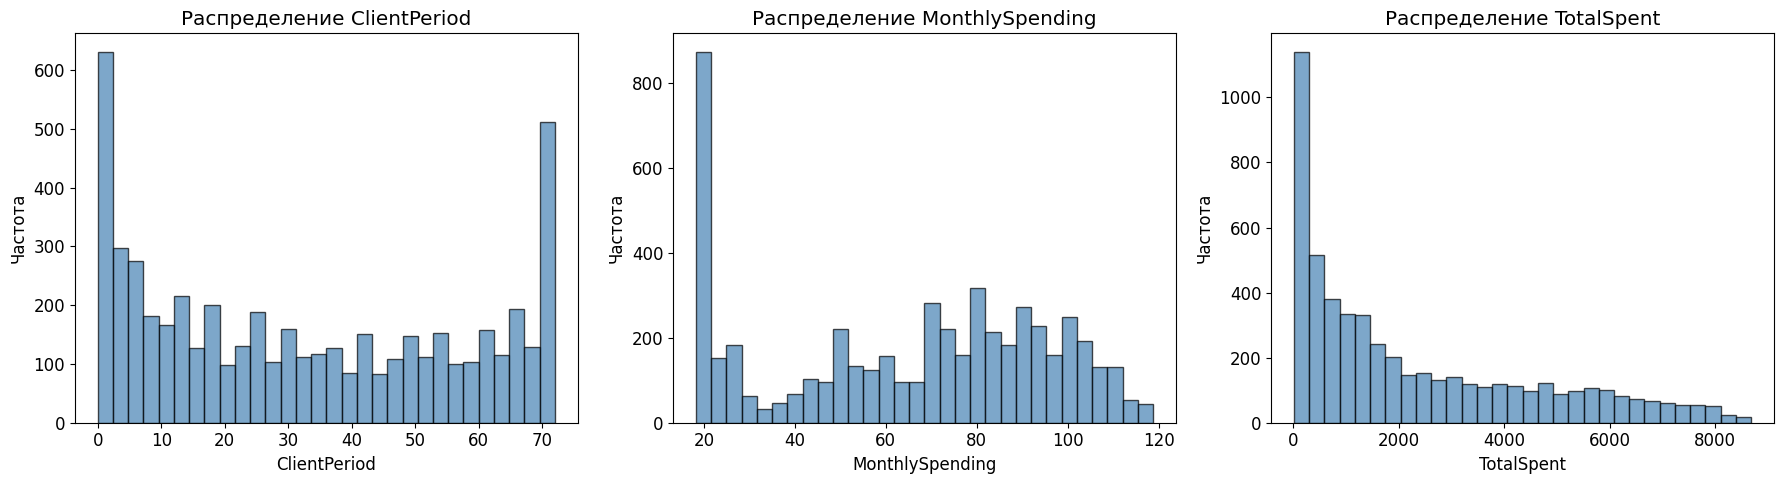

In [7]:
# Гистограммы для числовых признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

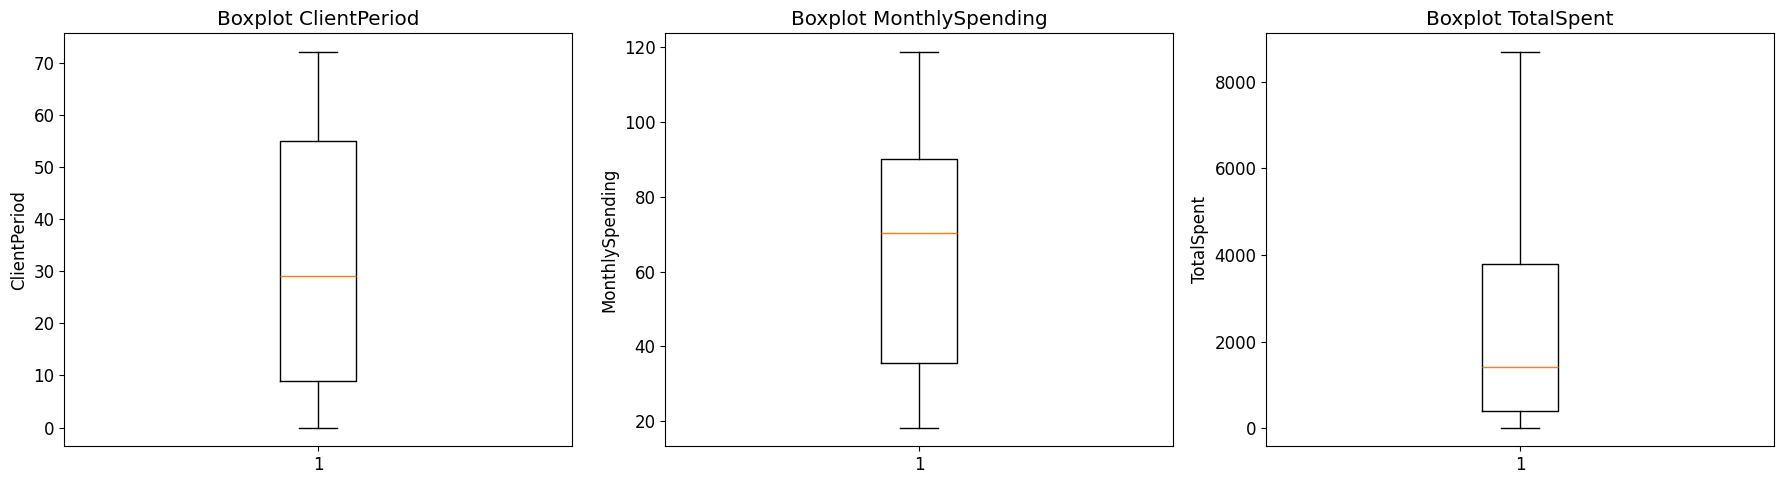

In [8]:
# Boxplot для числовых признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(data[col], vert=True)
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### 2.2 Категориальные признаки — value_counts и bar-диаграммы

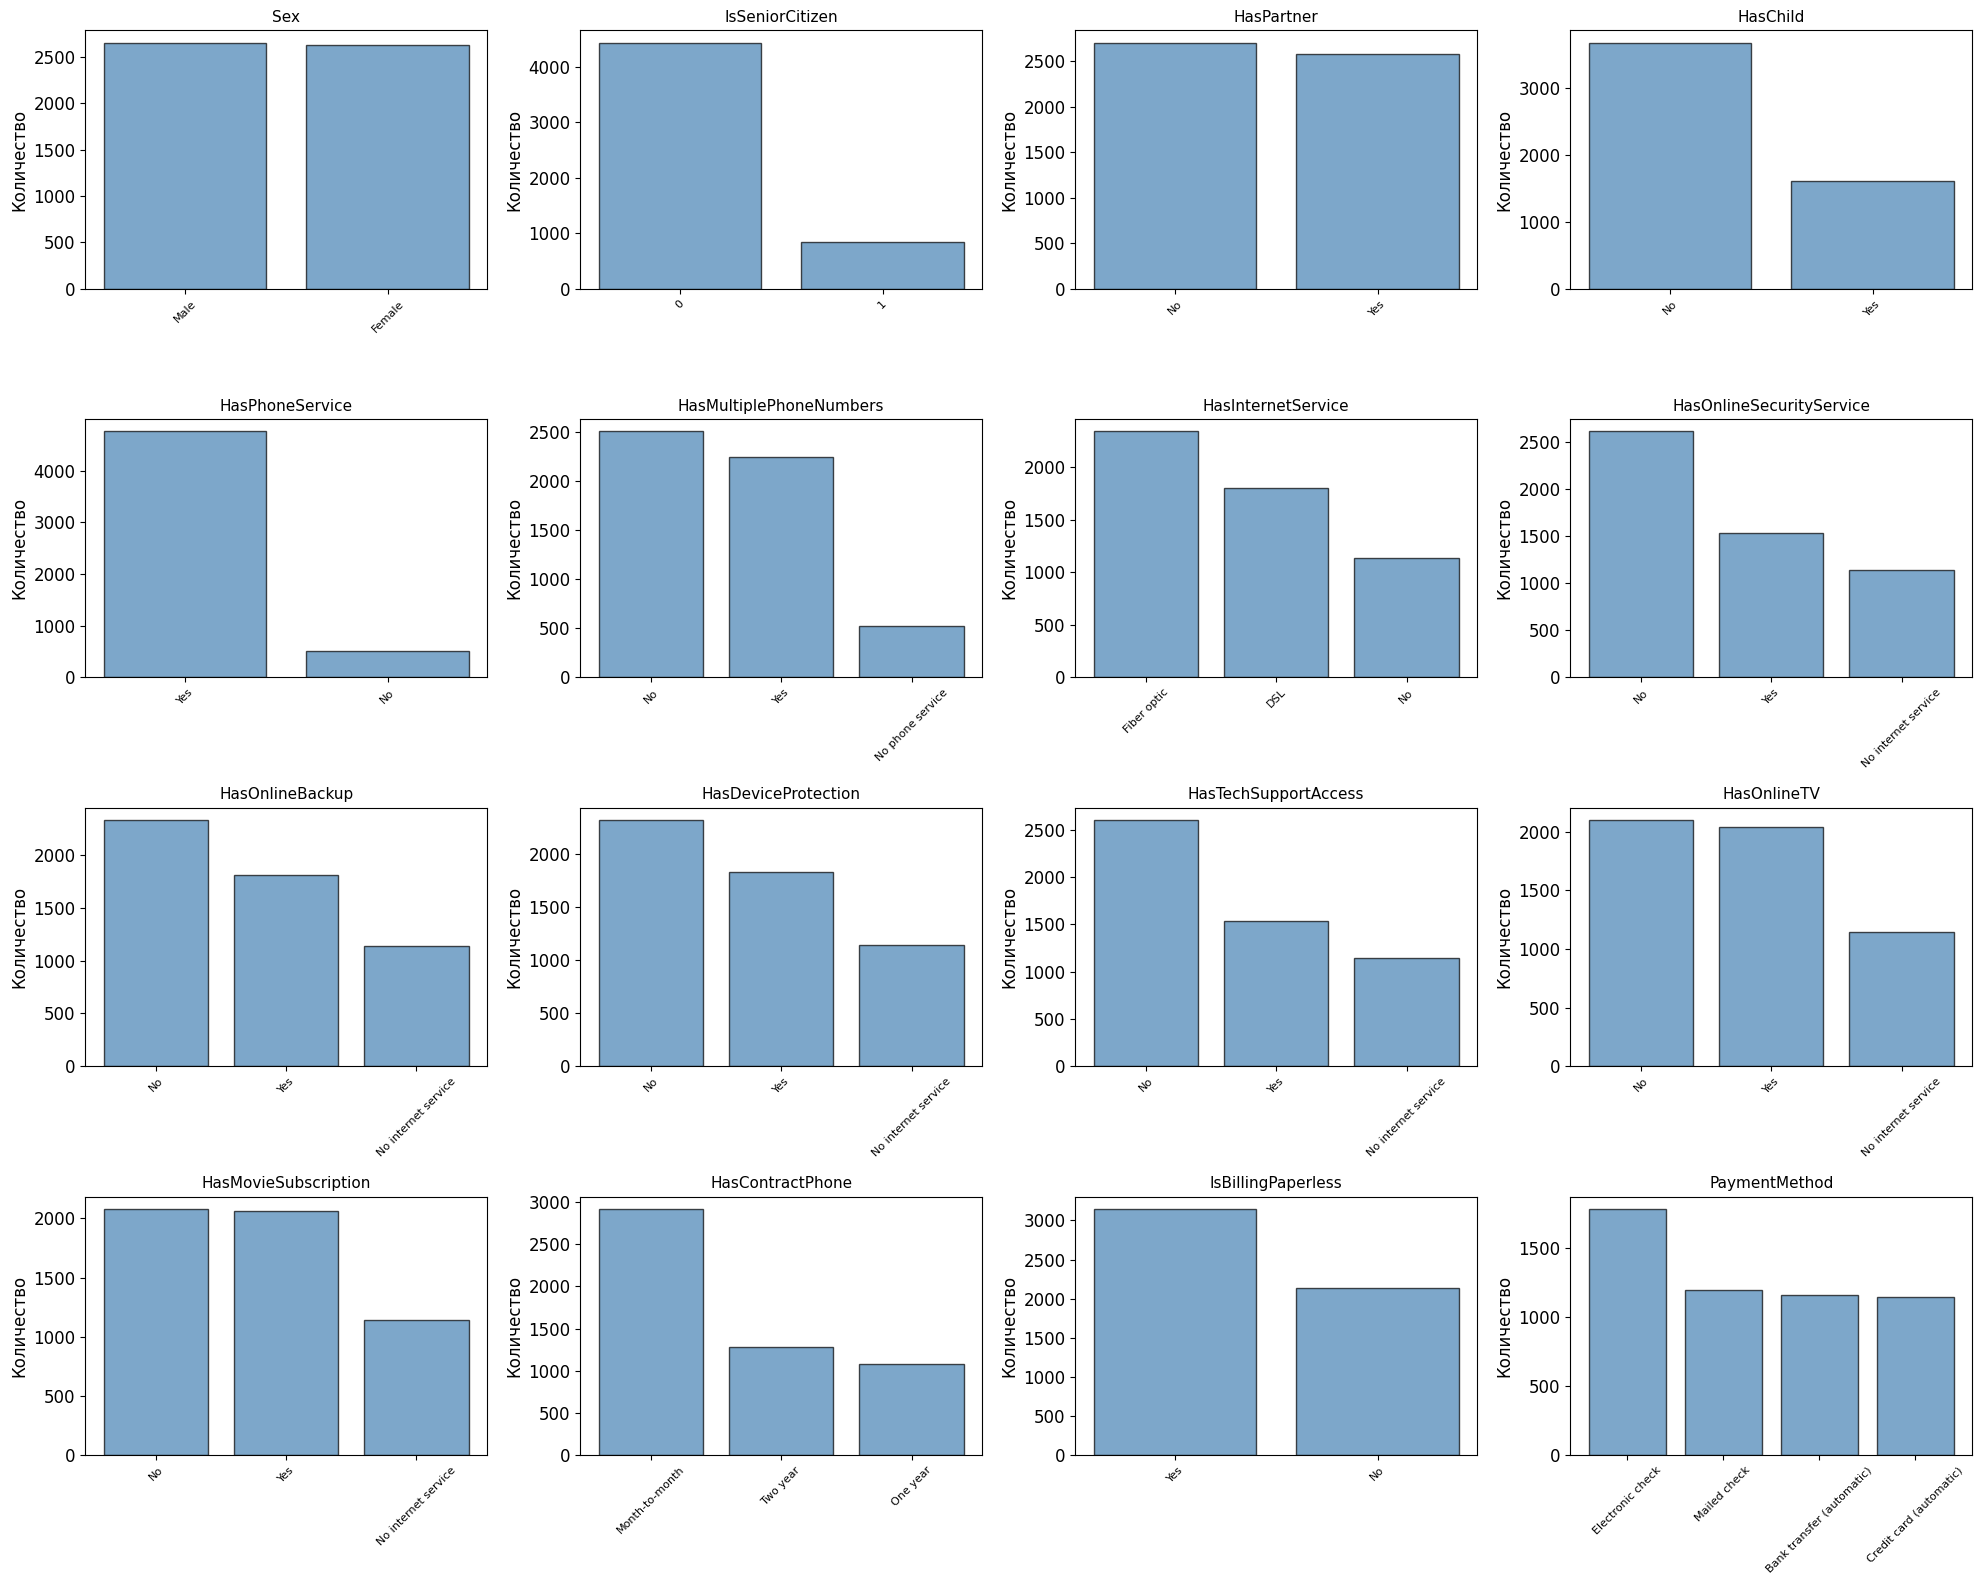

In [9]:
# Bar-диаграммы для всех категориальных признаков на одном графике (subplots)
n_cats = len(cat_cols)
n_rows = 4
n_cols_plot = 4

fig, axes = plt.subplots(n_rows, n_cols_plot, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = data[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_ylabel('Количество')

# Скрываем пустые оси (если есть)
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 2.3 Анализ дисбаланса целевой переменной

Распределение целевой переменной Churn:
Churn
0    3898
1    1384
Name: count, dtype: int64

Доля класса 1 (отток): 26.2%
Доля класса 0 (не отток): 73.8%
Соотношение классов: 1:2.8


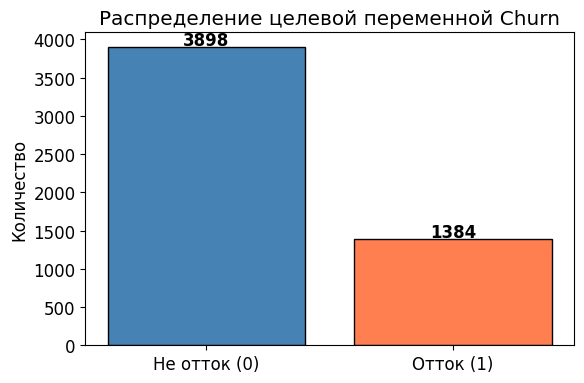


Классы умеренно несбалансированы (~74% vs ~26%). ROC-AUC — хорошая метрика для такого случая, так как она не зависит от порога классификации.


In [10]:
# Распределение целевой переменной
churn_counts = data[target_col].value_counts()
print('Распределение целевой переменной Churn:')
print(churn_counts)
print(f'\nДоля класса 1 (отток): {churn_counts[1] / len(data) * 100:.1f}%')
print(f'Доля класса 0 (не отток): {churn_counts[0] / len(data) * 100:.1f}%')
print(f'Соотношение классов: 1:{churn_counts[0] / churn_counts[1]:.1f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Не отток (0)', 'Отток (1)'], churn_counts.values, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Распределение целевой переменной Churn')
ax.set_ylabel('Количество')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nКлассы умеренно несбалансированы (~74% vs ~26%). '
      'ROC-AUC — хорошая метрика для такого случая, '
      'так как она не зависит от порога классификации.')

## 3. Применение линейных моделей (3 балла)

Обработка данных для LogisticRegression:
- Нормализация числовых признаков (StandardScaler)
- One-hot encoding категориальных признаков
- Подбор гиперпараметра C через LogisticRegressionCV

In [11]:
# Подготовка данных для линейной модели
X = data[feature_cols].copy()
y = data[target_col].copy()

# IsSeniorCitizen — числовой (0/1), но указан как категориальный.
# Для линейной модели приведём все категориальные к строкам перед one-hot encoding
for col in cat_cols:
    X[col] = X[col].astype(str)

# Нормализация числовых признаков
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X[num_cols]),
    columns=num_cols,
    index=X.index
)

# One-hot encoding категориальных признаков
X_cat_encoded = pd.get_dummies(X[cat_cols], drop_first=True).astype(int)

# Объединяем
X_prepared = pd.concat([X_num_scaled, X_cat_encoded], axis=1)

print(f'Размер подготовленных данных: {X_prepared.shape}')
print(f'Числовые колонки (нормализованные): {num_cols}')
print(f'Категориальные после one-hot: {X_cat_encoded.shape[1]} колонок')
print(f'Пропуски: {X_prepared.isna().sum().sum()}')
X_prepared.head()

Размер подготовленных данных: (5282, 30)
Числовые колонки (нормализованные): ['ClientPeriod', 'MonthlySpending', 'TotalSpent']
Категориальные после one-hot: 27 колонок
Пропуски: 0


,ClientPeriod,MonthlySpending,TotalSpent,Sex_Male,IsSeniorCitizen_1,HasPartner_Yes,HasChild_Yes,HasPhoneService_Yes,HasMultiplePhoneNumbers_No phone service,HasMultiplePhoneNumbers_Yes,...,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.920767,-1.505447,-0.557323,1,0,1,1,1,0,0,...,1,0,1,0,1,0,0,0,0,1
1,1.613288,-1.294998,-0.184235,1,0,1,0,1,0,1,...,1,0,1,0,0,1,0,1,0,0
2,-1.279005,0.363737,-0.976549,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
3,-0.016173,0.476418,0.123552,0,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
4,1.124450,1.667856,1.970998,0,0,1,1,1,0,1,...,0,1,0,1,0,1,0,1,0,0


In [12]:
# LogisticRegressionCV — автоматический подбор C по ROC-AUC
log_reg_cv = LogisticRegressionCV(
    Cs=[100, 10, 1, 0.1, 0.01, 0.001],
    scoring='roc_auc',
    refit=True,
    cv=5,
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)

log_reg_cv.fit(X_prepared, y)

# Лучший C
best_C = log_reg_cv.C_[0]
print(f'Лучший параметр C: {best_C}')

# ROC-AUC на кросс-валидации для лучшего C
# scores_ имеет форму (n_folds, n_Cs) для бинарной классификации
Cs_list = [100, 10, 1, 0.1, 0.01, 0.001]
best_C_idx = list(Cs_list).index(best_C)
cv_scores = log_reg_cv.scores_[1]  # scores для класса 1
mean_scores = cv_scores.mean(axis=0)

print(f'\nROC-AUC по кросс-валидации для каждого C:')
for c, score in zip(Cs_list, mean_scores):
    marker = ' <-- лучший' if c == best_C else ''
    print(f'  C={c:>6}: ROC-AUC = {score:.4f}{marker}')

best_logreg_auc = mean_scores[best_C_idx]
print(f'\nЛучший ROC-AUC (LogisticRegression): {best_logreg_auc:.4f}')

Лучший параметр C: 10.0

ROC-AUC по кросс-валидации для каждого C:
  C=   100: ROC-AUC = 0.8449
  C=    10: ROC-AUC = 0.8451 <-- лучший
  C=     1: ROC-AUC = 0.8449
  C=   0.1: ROC-AUC = 0.8437
  C=  0.01: ROC-AUC = 0.8391
  C= 0.001: ROC-AUC = 0.8329

Лучший ROC-AUC (LogisticRegression): 0.8451


## 4. Применение градиентного бустинга (2 балла)

CatBoost умеет работать с категориальными признаками напрямую (через `cat_features`), нормализация числовых не требуется.

In [13]:
# Подготовка данных для CatBoost
X_cb = data[feature_cols].copy()
y_cb = data[target_col].copy()

# CatBoost требует строковые категориальные признаки
for col in cat_cols:
    X_cb[col] = X_cb[col].astype(str)

# Разделение на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X_cb, y_cb, test_size=0.2, random_state=42, stratify=y_cb
)

print(f'Train: {X_train.shape}, Valid: {X_valid.shape}')
print(f'Доля класса 1 в train: {y_train.mean():.3f}')
print(f'Доля класса 1 в valid: {y_valid.mean():.3f}')

Train: (4225, 19), Valid: (1057, 19)
Доля класса 1 в train: 0.262
Доля класса 1 в valid: 0.262


In [14]:
# CatBoost со стандартными параметрами (baseline)
cb_baseline = CatBoostClassifier(
    random_state=42,
    verbose=0
)
cb_baseline.fit(X_train, y_train, cat_features=cat_cols)

y_pred_baseline = cb_baseline.predict_proba(X_valid)[:, 1]
baseline_auc = roc_auc_score(y_valid, y_pred_baseline)
print(f'CatBoost (baseline) ROC-AUC на valid: {baseline_auc:.4f}')

CatBoost (baseline) ROC-AUC на valid: 0.8544


In [15]:
# Подбор n_estimators и learning_rate
n_estimators_list = [100, 300, 500, 800, 1000]
learning_rate_list = [0.01, 0.03, 0.05, 0.1, 0.2]

best_auc = 0
best_params = {}
results = []

for n_est in n_estimators_list:
    for lr in learning_rate_list:
        model = CatBoostClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42,
            verbose=0
        )
        model.fit(X_train, y_train, cat_features=cat_cols)
        y_pred = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_pred)
        results.append({'n_estimators': n_est, 'learning_rate': lr, 'roc_auc': auc})
        
        if auc > best_auc:
            best_auc = auc
            best_params = {'n_estimators': n_est, 'learning_rate': lr}
            best_cb_model = model

results_df = pd.DataFrame(results)
print('Результаты подбора гиперпараметров CatBoost:')
print(results_df.pivot(index='n_estimators', columns='learning_rate', values='roc_auc').round(4).to_string())
print(f'\nЛучшие параметры: n_estimators={best_params["n_estimators"]}, learning_rate={best_params["learning_rate"]}')
print(f'Лучший ROC-AUC (CatBoost) на valid: {best_auc:.4f}')

Результаты подбора гиперпараметров CatBoost:
learning_rate    0.01    0.03    0.05    0.10    0.20
n_estimators                                         
100            0.8396  0.8522  0.8556  0.8565  0.8500
300            0.8546  0.8553  0.8545  0.8455  0.8299
500            0.8556  0.8561  0.8490  0.8369  0.8201
800            0.8576  0.8522  0.8427  0.8271  0.8116
1000           0.8586  0.8491  0.8399  0.8260  0.8096

Лучшие параметры: n_estimators=1000, learning_rate=0.01
Лучший ROC-AUC (CatBoost) на valid: 0.8586


## 5. Обучение лучшей модели на всех данных и генерация submission

Переобучим лучшую модель CatBoost на всём train и сделаем предсказания для test.

In [16]:
# Сравнение моделей
print('=== Сравнение моделей ===')
print(f'LogisticRegressionCV (лучший C={best_C}): ROC-AUC = {best_logreg_auc:.4f} (CV)')
print(f'CatBoost (n_estimators={best_params["n_estimators"]}, lr={best_params["learning_rate"]}): ROC-AUC = {best_auc:.4f} (valid)')
print()

if best_auc >= best_logreg_auc:
    print('Лучшая модель: CatBoost')
    use_catboost = True
else:
    print('Лучшая модель: LogisticRegression')
    use_catboost = False

=== Сравнение моделей ===
LogisticRegressionCV (лучший C=10.0): ROC-AUC = 0.8451 (CV)
CatBoost (n_estimators=1000, lr=0.01): ROC-AUC = 0.8586 (valid)

Лучшая модель: CatBoost


In [17]:
# Обучаем лучшую модель CatBoost на всём train
best_model = CatBoostClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    random_state=42,
    verbose=0
)
best_model.fit(X_cb, y_cb, cat_features=cat_cols)
print('Модель CatBoost обучена на всём train.')

Модель CatBoost обучена на всём train.


In [18]:
# Загрузка и обработка test данных
X_test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/submission.csv')

# Обработка TotalSpent в test (аналогично train)
X_test['TotalSpent'] = pd.to_numeric(X_test['TotalSpent'], errors='coerce')
X_test['TotalSpent'] = X_test['TotalSpent'].fillna(total_spent_median)  # Та же медиана из train

# Приведение категориальных к строкам
for col in cat_cols:
    X_test[col] = X_test[col].astype(str)

# Предсказания — вероятность класса 1
X_test_features = X_test[feature_cols]
submission['Churn'] = best_model.predict_proba(X_test_features)[:, 1]

# Сохранение
submission.to_csv('data/my_submission.csv', index=False)

print('Submission сохранён в data/my_submission.csv')
print(f'Размер: {submission.shape}')
print(f'\nПервые 10 строк:')
print(submission.head(10))
print(f'\nСтатистика предсказаний:')
print(submission['Churn'].describe())

Submission сохранён в data/my_submission.csv
Размер: (1761, 2)

Первые 10 строк:
   Id     Churn
0   0  0.026087
1   1  0.685076
2   2  0.608218
3   3  0.015281
4   4  0.004912
5   5  0.098914
6   6  0.294090
7   7  0.221331
8   8  0.062730
9   9  0.381719

Статистика предсказаний:
count    1761.000000
mean        0.244661
std         0.238915
min         0.003864
25%         0.036935
50%         0.156365
75%         0.401201
max         0.951279
Name: Churn, dtype: float64
